  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=79ce1eab25df3f85a16ea2cb250cafd9353dbe3328f52647467e38620449b42b
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


/tmp/ipykernel_937/2018305067.py:10: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2-small", device=device)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
--- Scanning Floor 5 for Induction Workers ---
Head 0: Induction Score = 0.3918
Head 1: Induction Score = 0.5326
Head 2: Induction Score = 0.0390
Head 3: Induction Score = 0.0694
Head 4: Induction Score = 0.0311
Head 5: Induction Score = 0.4627
Head 6: Induction Score = 0.0023
Head 7: Induction Score = 0.0204
Head 8: Induction Score = 0.3520
Head 9: Induction Score = 0.0761
Head 10: Induction Score = 0.0695
Head 11: Induction Score = 0.0281

🎯 Target Identified: Heads [0, 1, 5, 8] are operating as Induction Circuits!


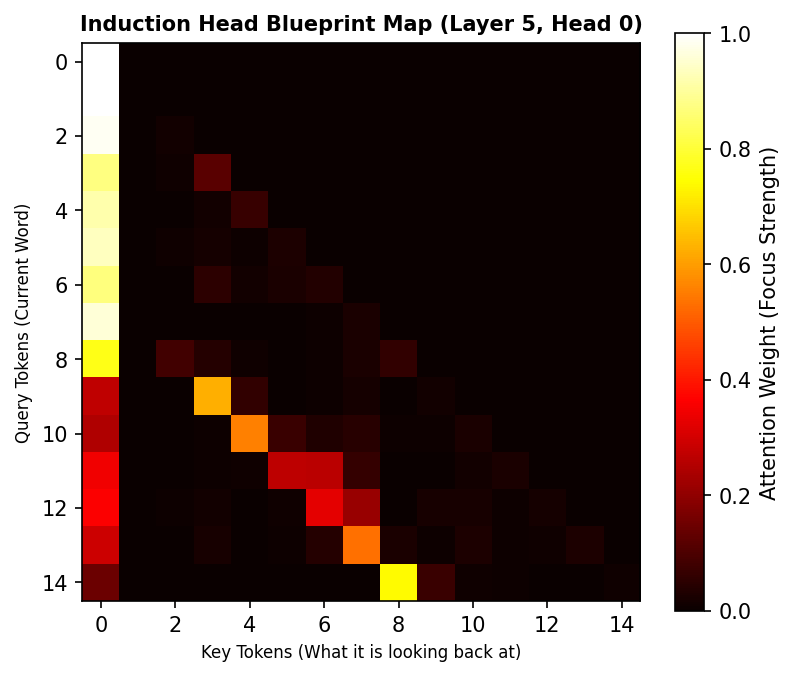

In [1]:
# 1. Initialize tools
!pip install transformer_lens torch matplotlib

import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# 2. Setup hardware accelerator and load the target model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# 3. Create a repeating token sequence pattern: [A][B][C][A][B]...
# Example: "The cat sat. The cat" -> Next token should be " sat"
text_pattern = "The cat sat on the mat. The cat sat on the mat."
tokens = model.to_tokens(text_pattern)
seq_len = tokens.shape[1]

# 4. Run the model and save the internal Attention Matrices
_, cache = model.run_with_cache(tokens)

# 5. Look at Floor 5 (Layer 5) where induction circuits typically form
layer_to_scan = 5
# Shape: [batch, num_heads, query_pos, key_pos]
attention_matrix = cache[f"blocks.{layer_to_scan}.attn.hook_pattern"][0]

# 6. Check for Induction Behavior
# An induction head at token position T looks back at position (T - Seq_Period + 1)
print(f"--- Scanning Floor {layer_to_scan} for Induction Workers ---")
induction_heads_found = []

for head in range(12):
    head_matrix = attention_matrix[head]

    # Measure the score of the diagonal shifted by our repeating phrase length
    # In "The cat sat on the mat. ", the phrase length is roughly 7 tokens.
    shift = 7
    diagonal_sum = 0
    count = 0

    for i in range(shift, seq_len):
        diagonal_sum += head_matrix[i, i - shift + 1].item()
        count += 1

    induction_score = diagonal_sum / count
    print(f"Head {head}: Induction Score = {induction_score:.4f}")

    if induction_score > 0.2: # Threshold for active copying behavior
        induction_heads_found.append(head)

print(f"\n🎯 Target Identified: Heads {induction_heads_found} are operating as Induction Circuits!")

# 7. Generate a visual blueprint map of the smartest head's attention pattern
best_head = induction_heads_found[0] if induction_heads_found else 0
plt.figure(figsize=(6, 5), dpi=150)
plt.imshow(attention_matrix[best_head].cpu().detach().numpy(), cmap='hot', origin='upper')
plt.title(f"Induction Head Blueprint Map (Layer {layer_to_scan}, Head {best_head})", fontsize=10, fontweight='bold')
plt.xlabel("Key Tokens (What it is looking back at)", fontsize=8)
plt.ylabel("Query Tokens (Current Word)", fontsize=8)
plt.colorbar(label="Attention Weight (Focus Strength)")
plt.savefig("induction_circuit_blueprint.png", bbox_inches='tight')
plt.show()
